In [25]:
import os
import re
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from glob import glob
from matplotlib import rcParams

# %matplotlib inline

# Plot style configuration
rcParams['mathtext.fontset'] = 'stix'
rcParams['font.family'] = 'STIXGeneral'
rcParams['figure.figsize'] = [16, 6]
rcParams['font.size'] = 22
rcParams['axes.labelsize'] = 20
rcParams['axes.titlesize'] = 20
rcParams['legend.fontsize'] = 16
rcParams['xtick.labelsize'] = 12
rcParams['ytick.labelsize'] = 16

from mpl_toolkits.mplot3d import Axes3D  

# Prevent ROOT errors and setup paths
root_path = "/scratch/elena/root-6.26.04-install"
os.environ["ROOTSYS"] = root_path
os.environ["PYTHONPATH"] = f"{root_path}/lib:{os.environ.get('PYTHONPATH', '')}"
os.environ["LD_LIBRARY_PATH"] = f"{root_path}/lib:{os.environ.get('LD_LIBRARY_PATH', '')}"
sys.path.append(f"{root_path}/lib")

os.environ["WCSIM_BUILD_DIR"] = "/scratch/elena/wcsim-install"
os.environ["BONSAIDIR"] = "/scratch/elena/bonsai"

sys.path.append("/scratch/elena/9Li/scripts")
import functions_bonsai
import functions_multilateration

# Paths configuration
processed_folder = "/scratch/elena/9Li/results/run1848/processed"

match = re.search(r'run(\d+)', processed_folder)
run_number = match.group(1) if match else "Not found!"
print(f"Run number extracted: {run_number}")

# ---------------------------------------------------------------
# 1. LOADING INITIAL DATA (Stage 3 outputs - Li9_chunk*.pkl)
# ---------------------------------------------------------------
print("\n[1/2] Loading Unfiltered Initial Data...")
all_initial_files = glob(f"{processed_folder}/Li9_clusters_chunk_*.pkl")

# Filter explicitly to avoid final merged pipeline files
files_init_sig = sorted([f for f in all_initial_files if not f.endswith('_BKG.pkl') and 'multilat' not in f])
files_init_bkg = sorted([f for f in all_initial_files if f.endswith('_BKG.pkl') and 'multilat' not in f])

df_initial_sig = pd.concat([pd.read_pickle(f) for f in files_init_sig], ignore_index=True) if files_init_sig else pd.DataFrame()
df_initial_bkg = pd.concat([pd.read_pickle(f) for f in files_init_bkg], ignore_index=True) if files_init_bkg else pd.DataFrame()

print(f"  -> Initial SIGNAL clusters loaded: {len(df_initial_sig)}")
print(f"  -> Initial BACKGROUND clusters loaded: {len(df_initial_bkg)}")

# ---------------------------------------------------------------
# 2. LOADING REFINED DATA (Stage 4 outputs - Refine*.pkl)
# ---------------------------------------------------------------
print("\n[2/2] Loading Refined Data...")
all_refined_files = glob(f"{processed_folder}/Refine_Li9_clusters_chunk_*.pkl")

files_ref_sig = sorted([f for f in all_refined_files if not f.endswith('_BKG.pkl')])
files_ref_bkg = sorted([f for f in all_refined_files if f.endswith('_BKG.pkl')])

df_refined_sig = pd.concat([pd.read_pickle(f) for f in files_ref_sig], ignore_index=True) if files_ref_sig else pd.DataFrame()
df_refined_bkg = pd.concat([pd.read_pickle(f) for f in files_ref_bkg], ignore_index=True) if files_ref_bkg else pd.DataFrame()

print(f"  -> Refined SIGNAL clusters loaded: {len(df_refined_sig)}")
print(f"  -> Refined BACKGROUND clusters loaded: {len(df_refined_bkg)}")

# Geometry setup
if len(df_initial_sig) > 0 or len(df_initial_bkg) > 0:
    geo_data = functions_bonsai.get_geo_mapping()
    lookup = functions_bonsai.build_lookup_table(geo_data)

print("\n===============================================================")
print(" ALL DATA LOADED SUCCESSFULLY! Ready to select sample and plot.")
print("===============================================================")

Run number extracted: 1848

[1/2] Loading Unfiltered Initial Data...
  -> Initial SIGNAL clusters loaded: 171656
  -> Initial BACKGROUND clusters loaded: 84406

[2/2] Loading Refined Data...
  -> Refined SIGNAL clusters loaded: 50976
  -> Refined BACKGROUND clusters loaded: 25271

 ALL DATA LOADED SUCCESSFULLY! Ready to select sample and plot.


Plotting Initial Distribution for: Signal_sample (Total clusters: 171656)
  -> Fit success counts: 171643


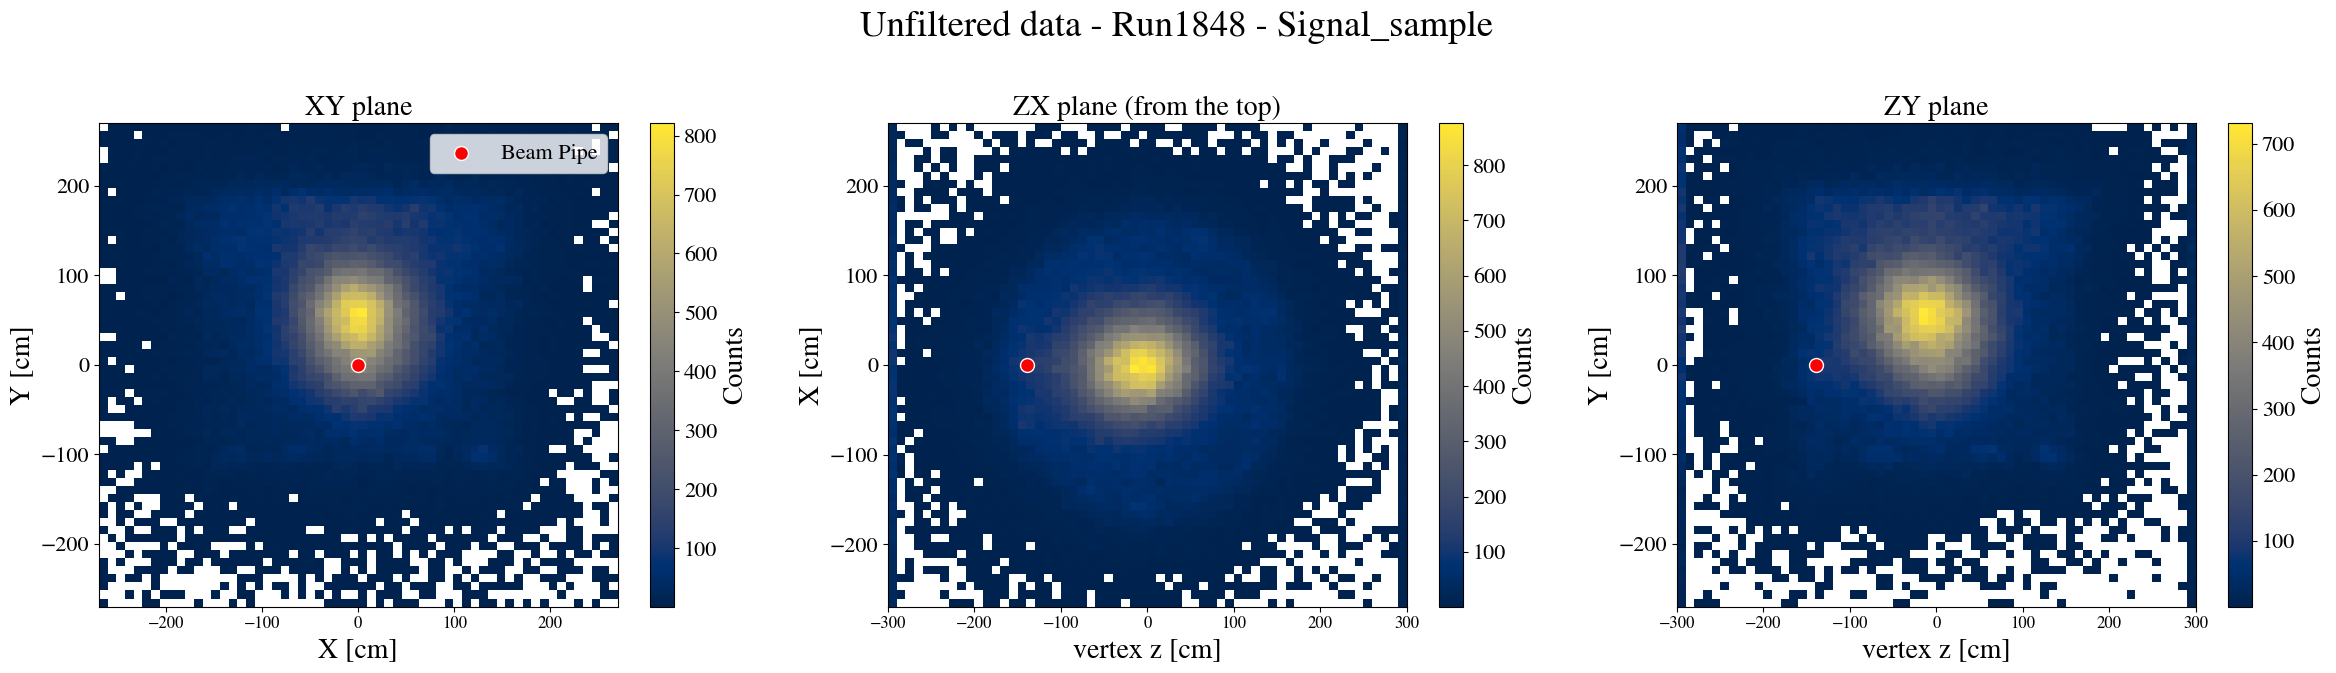

In [26]:
# ===============================================================
# SAMPLE VISUALIZATION CONFIGURATION
# Change here: df_initial_sig (for Signal) or df_initial_bkg (for Background)
# ===============================================================
df_all = df_initial_sig  
sample_label = "Signal_sample" if df_all is df_initial_sig else "Background_sample"

print(f"Plotting Initial Distribution for: {sample_label} (Total clusters: {len(df_all)})")

if not df_all.empty:
    if 'chi2_ndof' in df_all.columns:
        valid_fits = df_all[df_all['fit_success'] == True]
        print(f"  -> Fit success counts: {len(valid_fits)}")

    # Apply reconstruction basic mask
    mask = (df_all['fit_success'] == True) & \
           (df_all['vertex_x'].abs() < 270) & \
           (df_all['vertex_y'].abs() < 270)

    df_clean = df_all[mask].copy()

    # Generating the plots
    fig, axs = plt.subplots(1, 3, figsize=(24, 7))
    beam_pipe = [0.0, 0.0, -138.79] # Updated Y coordinate to 0.0 for WCTE data

    # XY Plane 
    im0 = axs[0].hist2d(df_clean['vertex_x'], df_clean['vertex_y'], bins=60, cmap='cividis', cmin=1)
    axs[0].scatter(beam_pipe[0], beam_pipe[1], color='red', s=100, edgecolors='white', label='Beam Pipe')
    axs[0].set_title("XY plane")
    axs[0].set_xlabel("X [cm]")
    axs[0].set_ylabel("Y [cm]")
    axs[0].legend(loc='upper right')
    plt.colorbar(im0[3], ax=axs[0], label='Counts')

    # ZX Plane 
    im1 = axs[1].hist2d(df_clean['vertex_z'], df_clean['vertex_x'], bins=60, cmap='cividis', cmin=1)
    axs[1].scatter(beam_pipe[2], beam_pipe[0], color='red', s=100, edgecolors='white')
    axs[1].set_title("ZX plane (from the top)")
    axs[1].set_xlabel("vertex z [cm]")
    axs[1].set_ylabel("X [cm]")
    plt.colorbar(im1[3], ax=axs[1], label='Counts')

    # ZY Plane 
    im2 = axs[2].hist2d(df_clean['vertex_z'], df_clean['vertex_y'], bins=60, cmap='cividis', cmin=1)
    axs[2].scatter(beam_pipe[2], beam_pipe[1], color='red', s=100, edgecolors='white')
    axs[2].set_title("ZY plane")
    axs[2].set_xlabel("vertex z [cm]")
    axs[2].set_ylabel("Y [cm]")
    plt.colorbar(im2[3], ax=axs[2], label='Counts')

    plt.suptitle(f"Unfiltered data - Run{run_number} - {sample_label}")
    plt.tight_layout()
    plt.show()
else:
    print("Error: selected DataFrame is empty.")

Plotting Refined Spatial Distribution for: Signal_sample (Total refined clusters: 50976)
  -> Fit success (Refined) counts: 50976


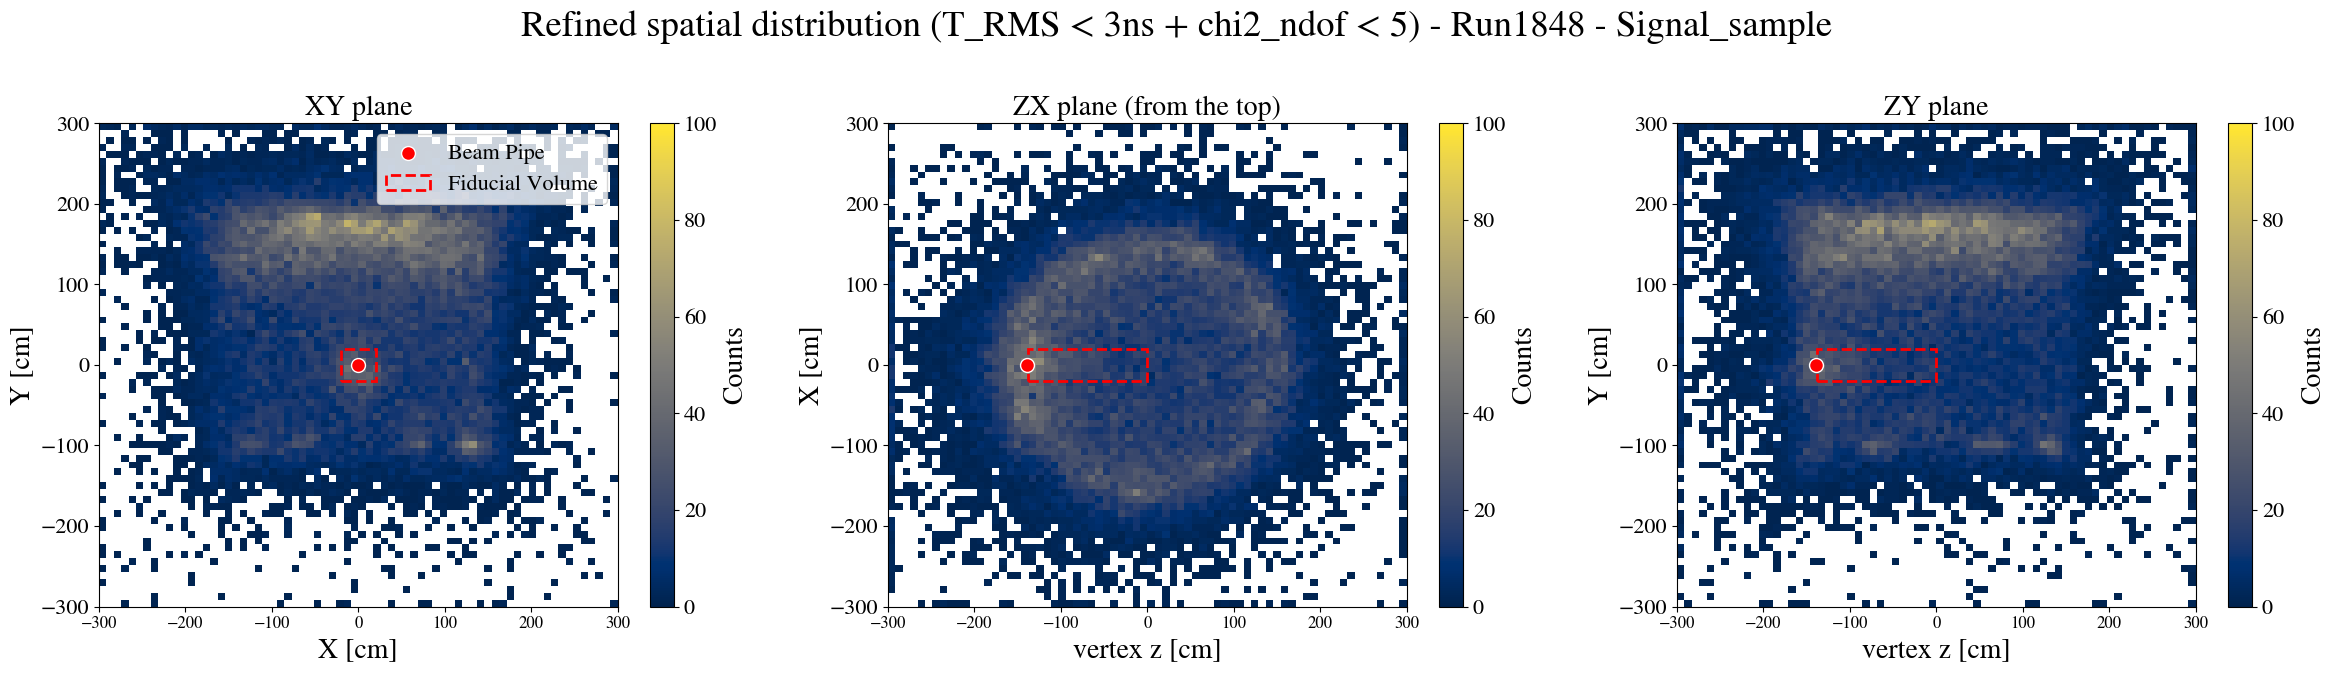


--- SELECTION METRICS (SIGNAL_SAMPLE) ---
Total clusters analyzed:           171656
Events satisfying mask (refined):  35641
Selection efficiency:              20.76%


In [27]:
# ===============================================================
# SAMPLE VISUALIZATION CONFIGURATION
# Change here: df_refined_sig (for Signal) or df_refined_bkg (for Background)
# NOTE: Ensure df_all (previous cell) matches the same sample type for valid statistics!
# ===============================================================
df_final = df_refined_sig  
sample_label = "Signal_sample" if df_final is df_refined_sig else "Background_sample"

print(f"Plotting Refined Spatial Distribution for: {sample_label} (Total refined clusters: {len(df_final)})")

if not df_final.empty:
    if 'chi2_ndof' in df_final.columns:
        valid_fits = df_final[df_final['fit_success'] == True]
        print(f"  -> Fit success (Refined) counts: {len(valid_fits)}")

    # Analysis mask for quality vertices
    mask_refined = (df_final['v_x_fine'].notna()) & \
                   (df_final["chi2_ndof"] < 5) 

    df_clean = df_final[mask_refined].copy()

    # Generating the plots
    fig, axs = plt.subplots(1, 3, figsize=(24, 7))
    beam_pipe = [0.0, 0.0, -138.79] # Updated Y coordinate to 0.0 for WCTE data

    # WCTE Updated Fiducial Volume Limits
    x_lims = [-20.0, 20.0]
    y_lims = [-20.0, 20.0]
    z_lims = [-138.0, 0.0]

    box_style = dict(linewidth=2, edgecolor='red', facecolor='none', linestyle='--')

    # XY plane
    im0 = axs[0].hist2d(df_clean['v_x_fine'], df_clean['v_y_fine'], bins=70, cmap='cividis', cmin=1, vmin=0, vmax=100)
    axs[0].scatter(beam_pipe[0], beam_pipe[1], color='red', s=100, edgecolors='white', label='Beam Pipe', zorder=10)
    
    rect_xy = patches.Rectangle((x_lims[0], y_lims[0]), x_lims[1]-x_lims[0], y_lims[1]-y_lims[0], **box_style, label='Fiducial Volume')
    axs[0].add_patch(rect_xy)
    
    axs[0].set_title("XY plane")
    axs[0].set_xlabel("X [cm]")
    axs[0].set_ylabel("Y [cm]")
    axs[0].legend(loc='upper right')
    plt.colorbar(im0[3], ax=axs[0], label='Counts')

    # ZX plane
    im1 = axs[1].hist2d(df_clean['v_z_fine'], df_clean['v_x_fine'], bins=70, cmap='cividis', cmin=1, vmin=0, vmax=100)
    axs[1].scatter(beam_pipe[2], beam_pipe[0], color='red', s=100, edgecolors='white', zorder=10)
    
    rect_zx = patches.Rectangle((z_lims[0], x_lims[0]), z_lims[1]-z_lims[0], x_lims[1]-x_lims[0], **box_style)
    axs[1].add_patch(rect_zx)
    
    axs[1].set_title("ZX plane (from the top)")
    axs[1].set_xlabel("vertex z [cm]")
    axs[1].set_ylabel("X [cm]")
    plt.colorbar(im1[3], ax=axs[1], label='Counts')

    # ZY plane
    im2 = axs[2].hist2d(df_clean['v_z_fine'], df_clean['v_y_fine'], bins=70, cmap='cividis', cmin=1, vmin=0, vmax=100)
    axs[2].scatter(beam_pipe[2], beam_pipe[1], color='red', s=100, edgecolors='white', zorder=10)
    
    rect_zy = patches.Rectangle((z_lims[0], y_lims[0]), z_lims[1]-z_lims[0], y_lims[1]-y_lims[0], **box_style)
    axs[2].add_patch(rect_zy)
    
    axs[2].set_title("ZY plane")
    axs[2].set_xlabel("vertex z [cm]")
    axs[2].set_ylabel("Y [cm]")
    plt.colorbar(im2[3], ax=axs[2], label='Counts')

    plt.suptitle(f"Refined spatial distribution (T_RMS < 3ns + chi2_ndof < 5) - Run{run_number} - {sample_label}")
    plt.tight_layout()
    plt.show()

    # --- Efficiency Calculation ---
    total_events = len(df_all)
    passed_events = len(df_clean)
    percentage = (passed_events / total_events) * 100 if total_events > 0 else 0.0

    print(f"\n--- SELECTION METRICS ({sample_label.upper()}) ---")
    print(f"Total clusters analyzed:           {total_events}")
    print(f"Events satisfying mask (refined):  {passed_events}")
    print(f"Selection efficiency:              {percentage:.2f}%")
else:
    print("Error: selected Refined DataFrame is empty.")

Plotting TARGETED ZOOM Spatial Distribution for: Signal_sample


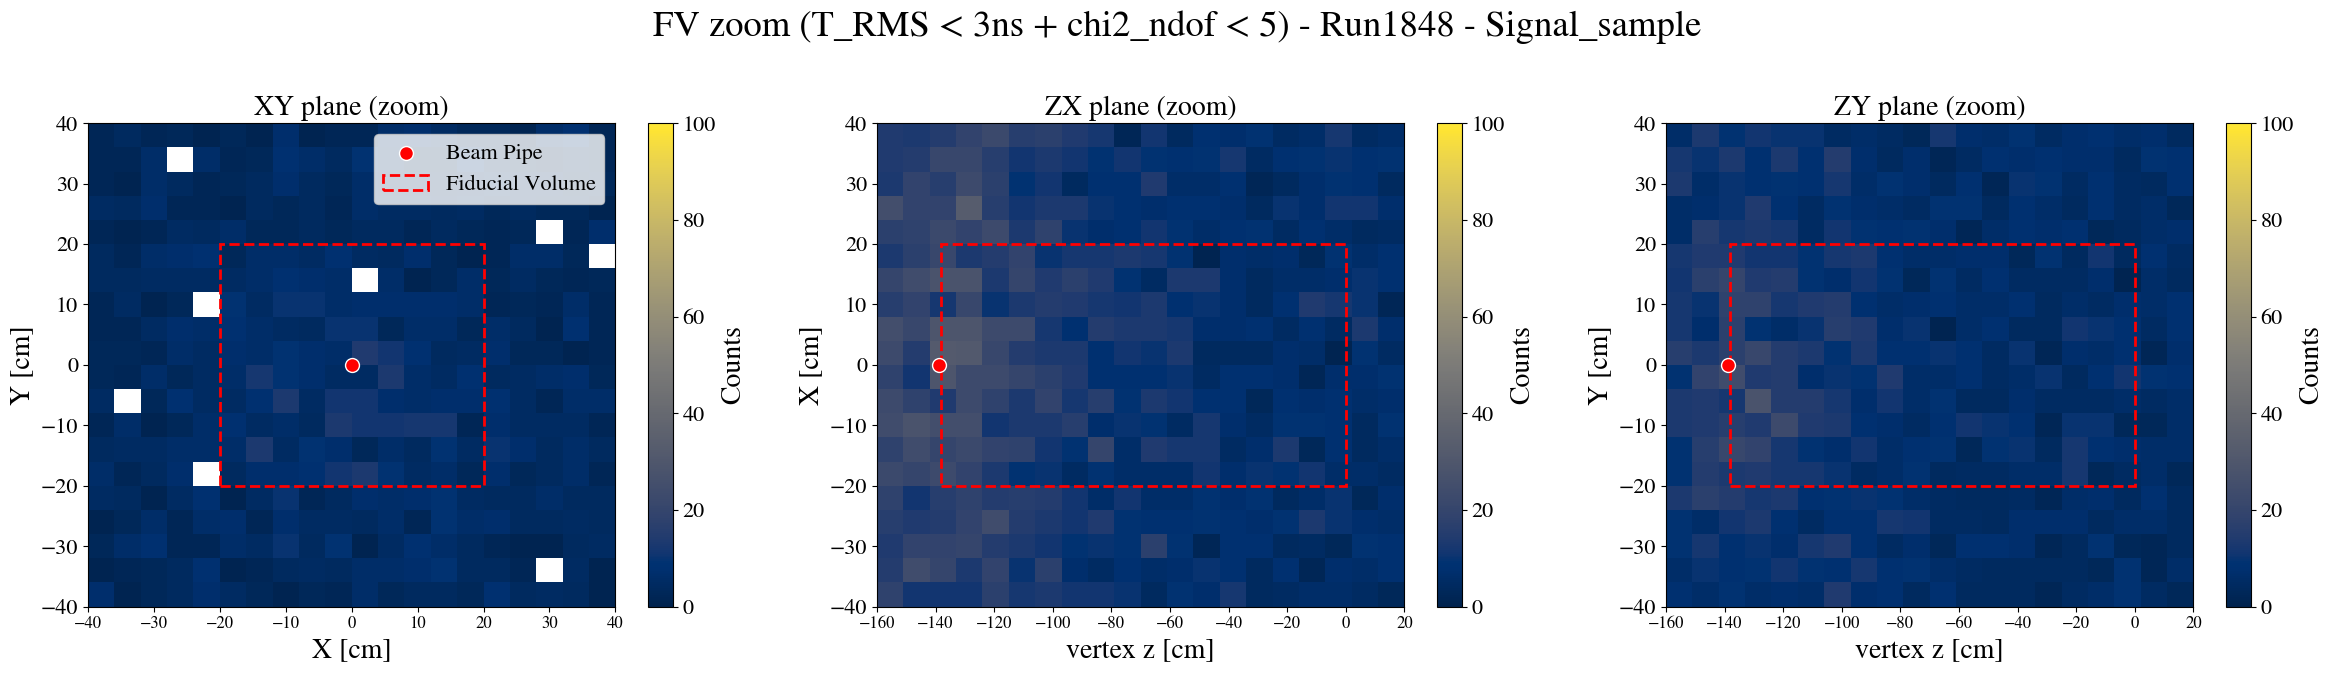

In [28]:
# ==============================================================================
# TARGETED ZOOM VISUALIZATION (BEAM PIPE & FV FOCUS ONLY)
# ==============================================================================
print(f"Plotting TARGETED ZOOM Spatial Distribution for: {sample_label}")

if not df_clean.empty:
    # Definimos los límites del zoom estricto alrededor del FV (con un margen de +20 cm)
    x_zoom = [-40.0, 40.0]
    y_zoom = [-40.0, 40.0]
    z_zoom = [-160.0, 20.0]

    # Generamos el lienzo clonando tu estructura exacta
    fig, axs = plt.subplots(1, 3, figsize=(24, 7))

    # 1. Plano XY (Zoom Enfocado)
    im0 = axs[0].hist2d(df_clean['v_x_fine'], df_clean['v_y_fine'], bins=20, 
                       range=[x_zoom, y_zoom], cmap='cividis', cmin=1, vmin=0, vmax=100)
    axs[0].scatter(beam_pipe[0], beam_pipe[1], color='red', s=100, edgecolors='white', label='Beam Pipe', zorder=10)
    
    rect_xy_zoom = patches.Rectangle((x_lims[0], y_lims[0]), x_lims[1]-x_lims[0], y_lims[1]-y_lims[0], **box_style, label='Fiducial Volume')
    axs[0].add_patch(rect_xy_zoom)
    
    axs[0].set_title("XY plane (zoom)")
    axs[0].set_xlabel("X [cm]")
    axs[0].set_ylabel("Y [cm]")
    axs[0].legend(loc='upper right')
    plt.colorbar(im0[3], ax=axs[0], label='Counts')

    # 2. Plano ZX (Zoom Enfocado)
    im1 = axs[1].hist2d(df_clean['v_z_fine'], df_clean['v_x_fine'], bins=20, 
                       range=[z_zoom, x_zoom], cmap='cividis', cmin=1, vmin=0, vmax=100)
    axs[1].scatter(beam_pipe[2], beam_pipe[0], color='red', s=100, edgecolors='white', zorder=10)
    
    rect_zx_zoom = patches.Rectangle((z_lims[0], x_lims[0]), z_lims[1]-z_lims[0], x_lims[1]-x_lims[0], **box_style)
    axs[1].add_patch(rect_zx_zoom)
    
    axs[1].set_title("ZX plane (zoom)")
    axs[1].set_xlabel("vertex z [cm]")
    axs[1].set_ylabel("X [cm]")
    plt.colorbar(im1[3], ax=axs[1], label='Counts')

    # 3. Plano ZY (Zoom Enfocado)
    im2 = axs[2].hist2d(df_clean['v_z_fine'], df_clean['v_y_fine'], bins=20, 
                       range=[z_zoom, y_zoom], cmap='cividis', cmin=1, vmin=0, vmax=100)
    axs[2].scatter(beam_pipe[2], beam_pipe[1], color='red', s=100, edgecolors='white', zorder=10)
    
    rect_zy_zoom = patches.Rectangle((z_lims[0], y_lims[0]), z_lims[1]-z_lims[0], y_lims[1]-y_lims[0], **box_style)
    axs[2].add_patch(rect_zy_zoom)
    
    axs[2].set_title("ZY plane (zoom)")
    axs[2].set_xlabel("vertex z [cm]")
    axs[2].set_ylabel("Y [cm]")
    plt.colorbar(im2[3], ax=axs[2], label='Counts')

    plt.suptitle(f"FV zoom (T_RMS < 3ns + chi2_ndof < 5) - Run{run_number} - {sample_label}")
    plt.tight_layout()
    plt.show()
else:
    print("Error: clean data is empty for plotting zoom.")

Plotting Refined Spatial Distribution for: Background_sample (Total refined clusters: 25271)
  -> Fit success (Refined) counts: 25271


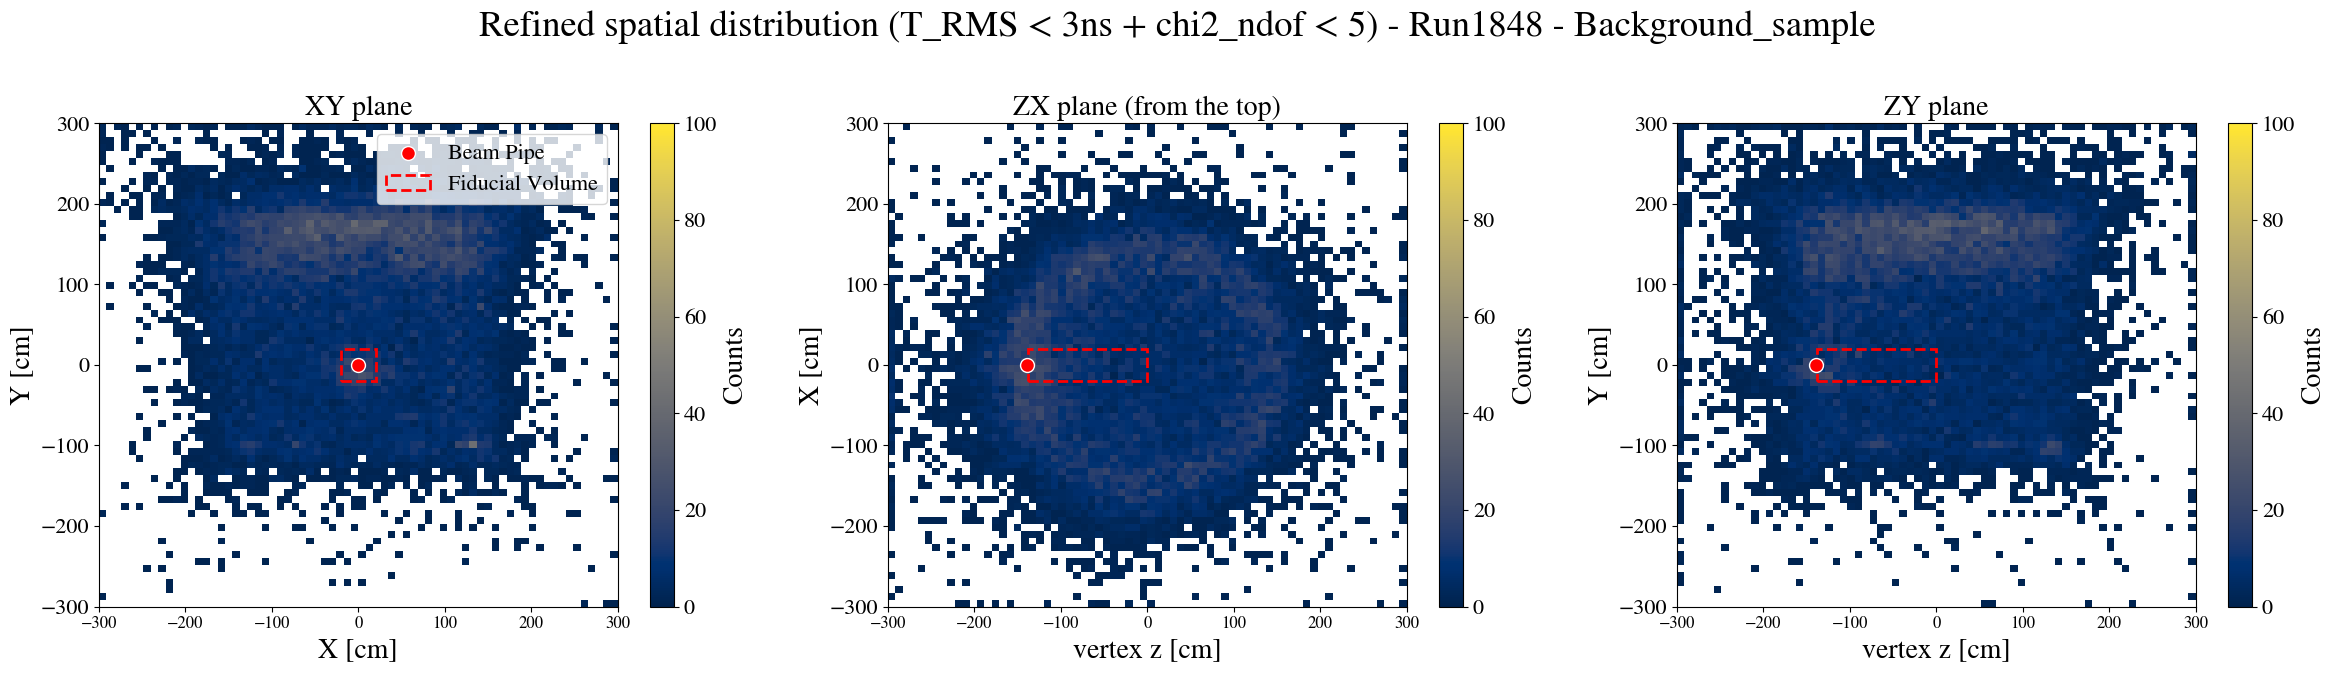


--- SELECTION METRICS (BACKGROUND_SAMPLE) ---
Total clusters analyzed:           171656
Events satisfying mask (refined):  17652
Selection efficiency:              10.28%


In [29]:
# ===============================================================
# SAMPLE VISUALIZATION CONFIGURATION
# Change here: df_refined_sig (for Signal) or df_refined_bkg (for Background)
# NOTE: Ensure df_all (previous cell) matches the same sample type for valid statistics!
# ===============================================================
df_final = df_refined_bkg
sample_label = "Signal_sample" if df_final is df_refined_sig else "Background_sample"

print(f"Plotting Refined Spatial Distribution for: {sample_label} (Total refined clusters: {len(df_final)})")

if not df_final.empty:
    if 'chi2_ndof' in df_final.columns:
        valid_fits = df_final[df_final['fit_success'] == True]
        print(f"  -> Fit success (Refined) counts: {len(valid_fits)}")

    # Analysis mask for quality vertices
    mask_refined = (df_final['v_x_fine'].notna()) & \
                   (df_final["chi2_ndof"] < 5) 

    df_clean = df_final[mask_refined].copy()

    # Generating the plots
    fig, axs = plt.subplots(1, 3, figsize=(24, 7))
    beam_pipe = [0.0, 0.0, -138.79] # Updated Y coordinate to 0.0 for WCTE data

    # WCTE Updated Fiducial Volume Limits
    x_lims = [-20.0, 20.0]
    y_lims = [-20.0, 20.0]
    z_lims = [-138.0, 0.0]

    box_style = dict(linewidth=2, edgecolor='red', facecolor='none', linestyle='--')

    # XY plane
    im0 = axs[0].hist2d(df_clean['v_x_fine'], df_clean['v_y_fine'], bins=70, cmap='cividis', cmin=1, vmin=0, vmax=100)
    axs[0].scatter(beam_pipe[0], beam_pipe[1], color='red', s=100, edgecolors='white', label='Beam Pipe', zorder=10)
    
    rect_xy = patches.Rectangle((x_lims[0], y_lims[0]), x_lims[1]-x_lims[0], y_lims[1]-y_lims[0], **box_style, label='Fiducial Volume')
    axs[0].add_patch(rect_xy)
    
    axs[0].set_title("XY plane")
    axs[0].set_xlabel("X [cm]")
    axs[0].set_ylabel("Y [cm]")
    axs[0].legend(loc='upper right')
    plt.colorbar(im0[3], ax=axs[0], label='Counts')

    # ZX plane
    im1 = axs[1].hist2d(df_clean['v_z_fine'], df_clean['v_x_fine'], bins=70, cmap='cividis', cmin=1, vmin=0, vmax=100)
    axs[1].scatter(beam_pipe[2], beam_pipe[0], color='red', s=100, edgecolors='white', zorder=10)
    
    rect_zx = patches.Rectangle((z_lims[0], x_lims[0]), z_lims[1]-z_lims[0], x_lims[1]-x_lims[0], **box_style)
    axs[1].add_patch(rect_zx)
    
    axs[1].set_title("ZX plane (from the top)")
    axs[1].set_xlabel("vertex z [cm]")
    axs[1].set_ylabel("X [cm]")
    plt.colorbar(im1[3], ax=axs[1], label='Counts')

    # ZY plane
    im2 = axs[2].hist2d(df_clean['v_z_fine'], df_clean['v_y_fine'], bins=70, cmap='cividis', cmin=1, vmin=0, vmax=100)
    axs[2].scatter(beam_pipe[2], beam_pipe[1], color='red', s=100, edgecolors='white', zorder=10)
    
    rect_zy = patches.Rectangle((z_lims[0], y_lims[0]), z_lims[1]-z_lims[0], y_lims[1]-y_lims[0], **box_style)
    axs[2].add_patch(rect_zy)
    
    axs[2].set_title("ZY plane")
    axs[2].set_xlabel("vertex z [cm]")
    axs[2].set_ylabel("Y [cm]")
    plt.colorbar(im2[3], ax=axs[2], label='Counts')

    plt.suptitle(f"Refined spatial distribution (T_RMS < 3ns + chi2_ndof < 5) - Run{run_number} - {sample_label}")
    plt.tight_layout()
    plt.show()

    # --- Efficiency Calculation ---
    total_events = len(df_all)
    passed_events = len(df_clean)
    percentage = (passed_events / total_events) * 100 if total_events > 0 else 0.0

    print(f"\n--- SELECTION METRICS ({sample_label.upper()}) ---")
    print(f"Total clusters analyzed:           {total_events}")
    print(f"Events satisfying mask (refined):  {passed_events}")
    print(f"Selection efficiency:              {percentage:.2f}%")
else:
    print("Error: selected Refined DataFrame is empty.")

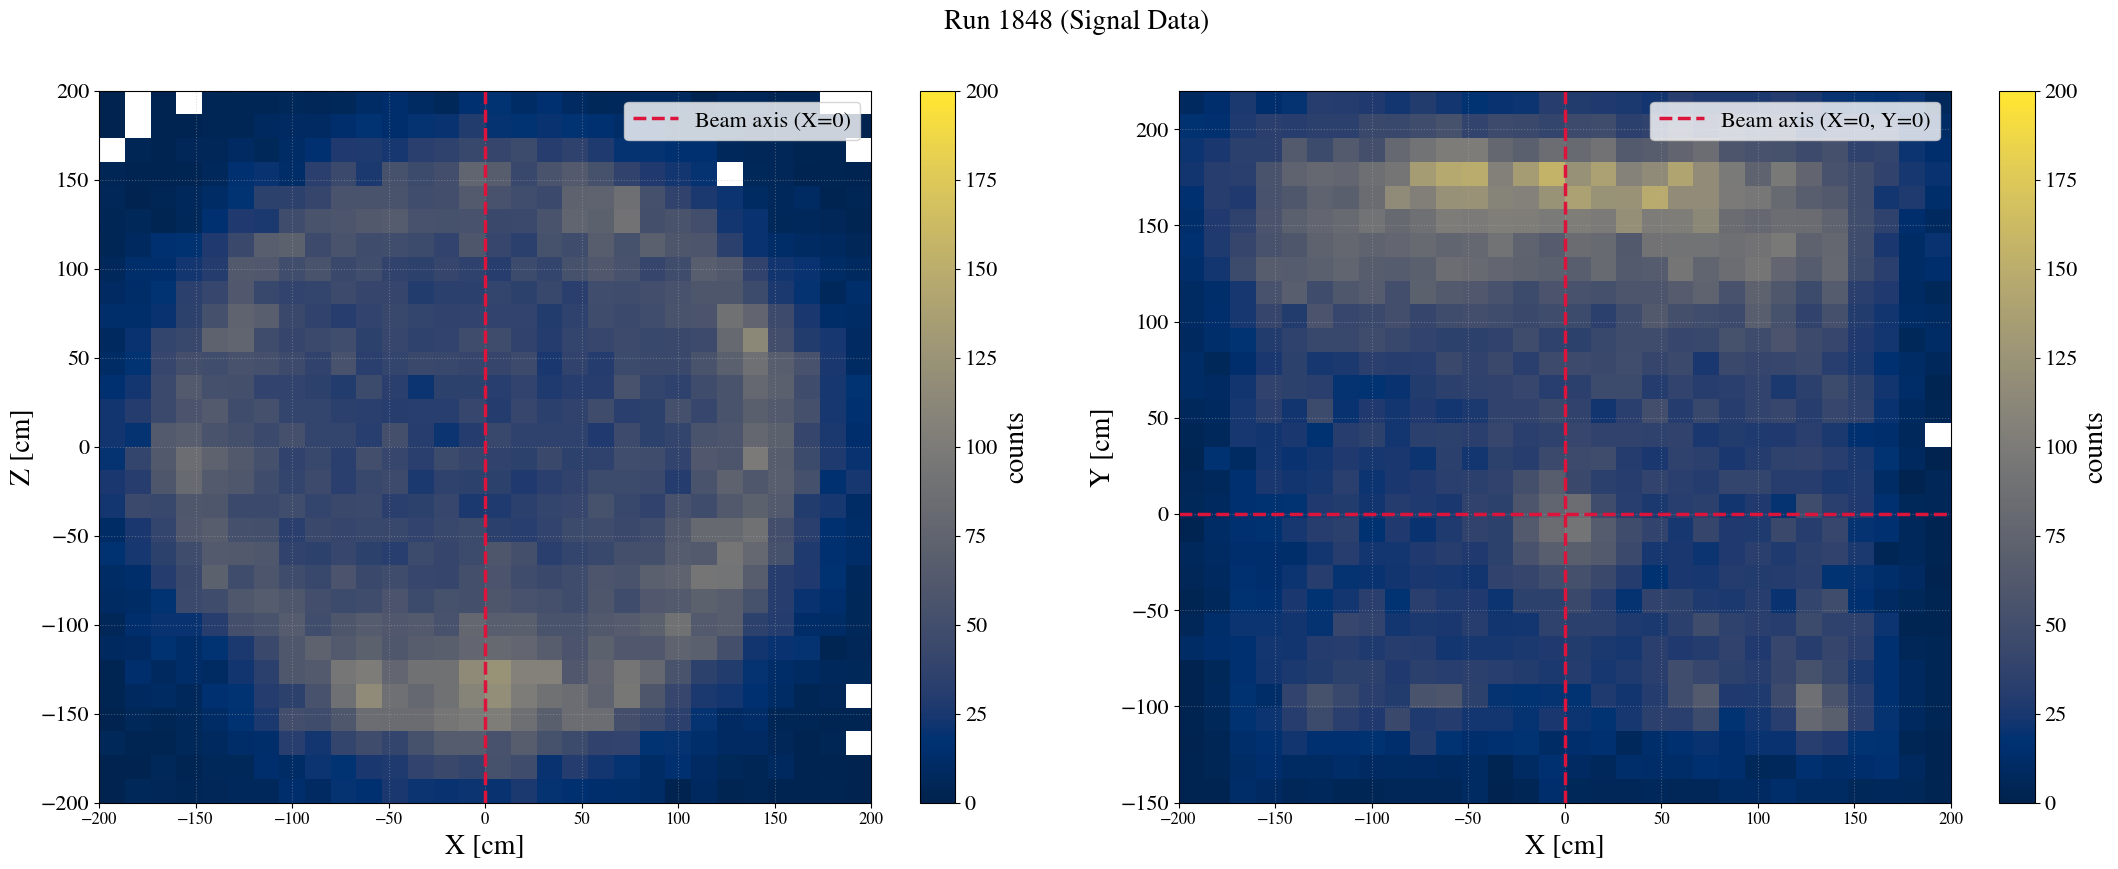

In [35]:
df_final = df_refined_sig  # Cambiar a df_refined_bkg si se quiere ver el fondo
sample_label = "Signal" if df_final is df_refined_sig else "Background"

# Filtro básico de calidad
mask_refined = df_final["v_x_fine"].notna() & (df_final["chi2_ndof"] < 5)
df_plot = df_final[mask_refined].copy()

# Configuramos el lienzo con dos paneles horizontales elegantes
fig, axs = plt.subplots(1, 2, figsize=(22, 9))

# --- CONFIGURACIÓN DE RANGOS TOTALES DEL DETECTOR (Estilo ROOT/WCTE) ---
# Límites globales del tanque: X:[-200, 200], Y:[-150, 220], Z:[-200, 200]
xlim_total = [-200.0, 200.0]
ylim_total = [-150.0, 220.0]
zlim_total = [-200.0, 200.0]

# ------------------------------------------------------------------------------
# PANEL 1: PROYECCIÓN ZX (Plano horizontal - Vista superior)
# ------------------------------------------------------------------------------
im0 = axs[0].hist2d(
    df_plot["v_x_fine"],
    df_plot["v_z_fine"],
    bins=[30, 30],
    range=[xlim_total, zlim_total],
    cmap="cividis",
    cmin=1,
    vmin=0,
    vmax=200
)

# Línea discontinua roja marcando el eje central del haz en X = 0
axs[0].axvline(
    0.0,
    color="crimson",
    linestyle="--",
    linewidth=2.5,
    label="Beam axis (X=0)",
)

axs[0].set_xlabel("X [cm]")
axs[0].set_ylabel("Z [cm]")
axs[0].grid(True, which="both", linestyle=":", alpha=0.4)
axs[0].legend(loc="upper right", frameon=True)
fig.colorbar(im0[3], ax=axs[0], label="counts")

# ------------------------------------------------------------------------------
# PANEL 2: PROYECCIÓN YX (Plano vertical - Vista frontal)
# ------------------------------------------------------------------------------
im1 = axs[1].hist2d(
    df_plot["v_x_fine"],
    df_plot["v_y_fine"],
    bins=[30, 30],
    range=[xlim_total, ylim_total],
    cmap="cividis",
    cmin=1,
    vmin=0,
    vmax=200
)

# Cruz de referencia del haz: centrado e impecable en (X=0, Y=0)
axs[1].axvline(0.0, color="crimson", linestyle="--", linewidth=2.5)
axs[1].axhline(
    0.0,
    color="crimson",
    linestyle="--",
    linewidth=2.5,
    label="Beam axis (X=0, Y=0)",
)

axs[1].set_xlabel("X [cm]")
axs[1].set_ylabel("Y [cm]")
axs[1].grid(True, which="both", linestyle=":", alpha=0.4)
axs[1].legend(loc="upper right", frameon=True)
fig.colorbar(im1[3], ax=axs[1], label="counts")

# --- TITULAR SUPERIOR DE LA FIGURA ---
run_info = f"Run {run_number}" if "run_number" in locals() else "All Combined Runs"
plt.suptitle(
    f"{run_info} ({sample_label} Data)",
    fontsize=20,
    y=0.98,
)

plt.tight_layout()
plt.show()

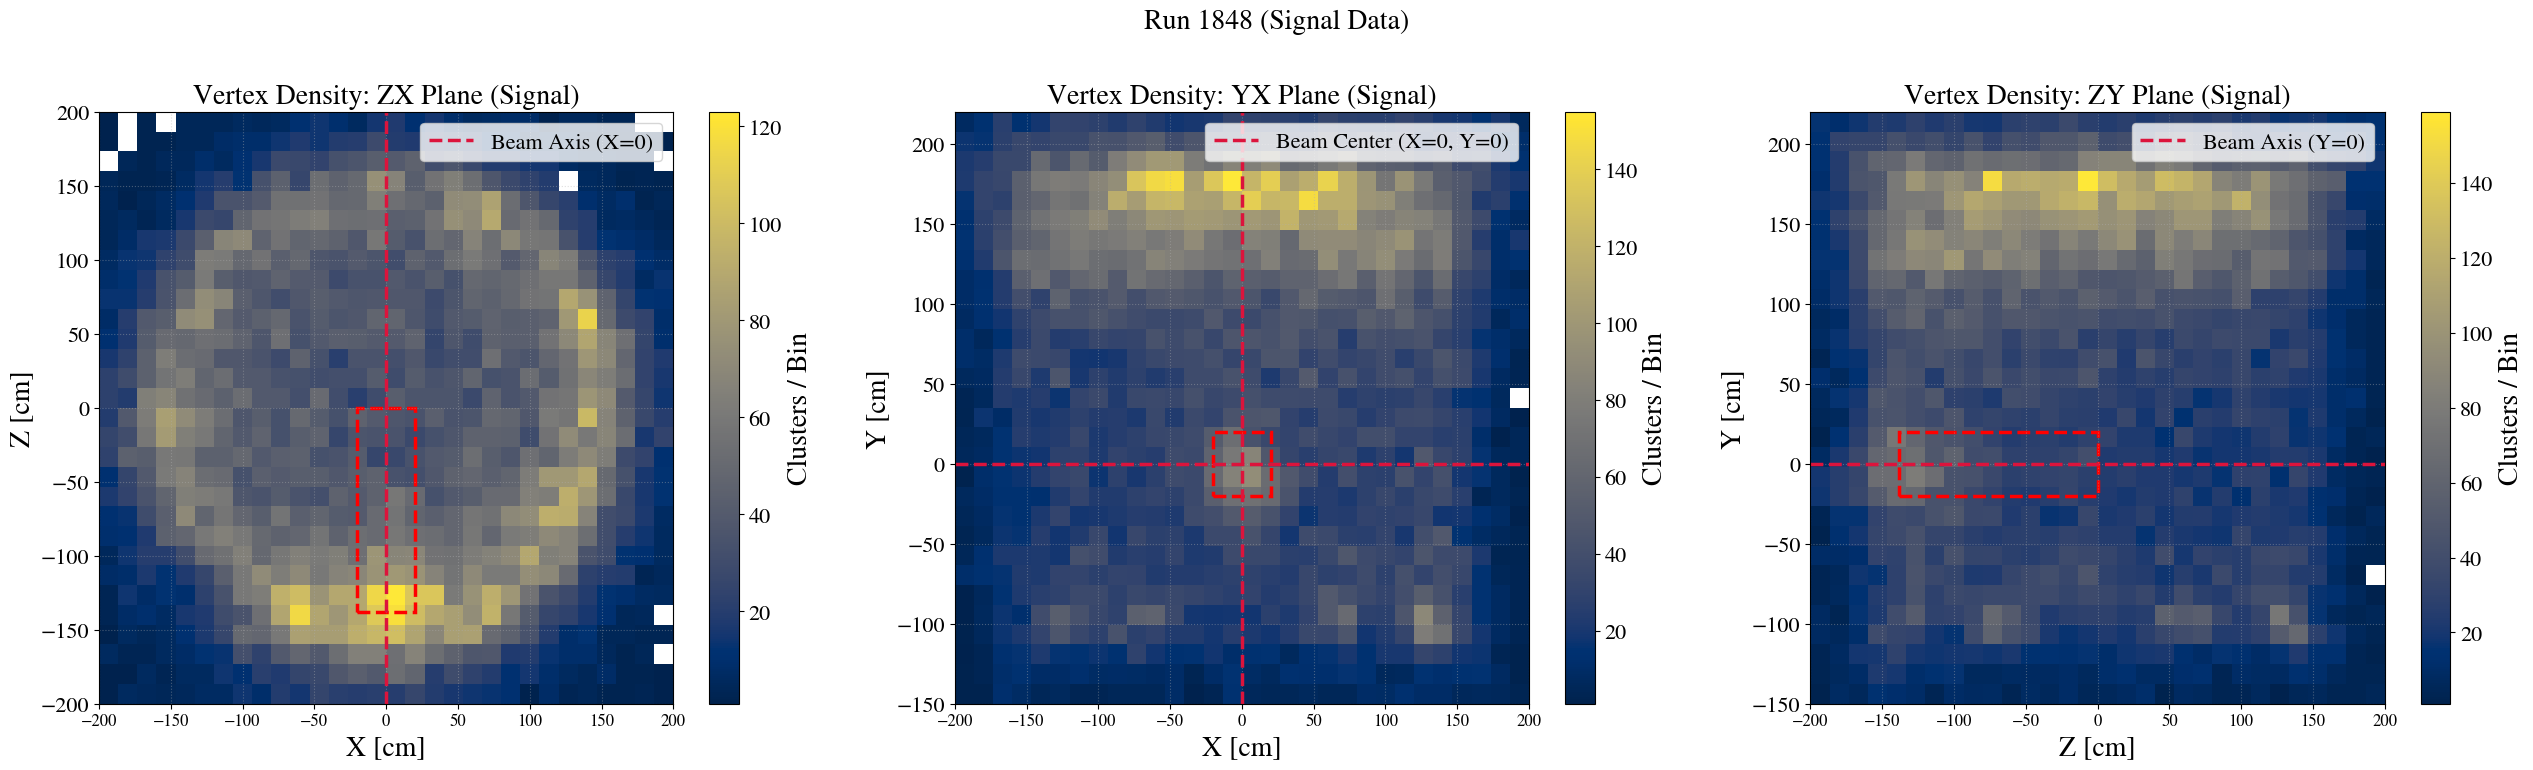

In [31]:
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np

df_final = df_refined_sig  # Cambiar a df_refined_bkg si se quiere ver el fondo
sample_label = "Signal" if df_final is df_refined_sig else "Background"

# Filtro básico de calidad
mask_refined = df_final["v_x_fine"].notna() & (df_final["chi2_ndof"] < 5)
df_plot = df_final[mask_refined].copy()

# CONFIGURAMOS EL LIENZO CON TRES PANELES HORIZONTALES ELEGANTES
fig, axs = plt.subplots(1, 3, figsize=(26, 8))

# --- CONFIGURACIÓN DE RANGOS TOTALES DEL DETECTOR (Estilo ROOT/WCTE) ---
xlim_total = [-200.0, 200.0]
ylim_total = [-150.0, 220.0]
zlim_total = [-200.0, 200.0]

# --- COORDENADAS DEL FIDUCIAL VOLUME (FV) ---
x_fv = [-20.0, 20.0]
y_fv = [-20.0, 20.0]
z_fv = [-138.0, 0.0]

# Estilo para las cajas del Fiducial Volume
fv_box_style = dict(
    linewidth=2.5, edgecolor="red", facecolor="none", linestyle="--"
)

# ------------------------------------------------------------------------------
# PANEL 1: PROYECCIÓN ZX (Plano horizontal - Vista superior)
# ------------------------------------------------------------------------------
im0 = axs[0].hist2d(
    df_plot["v_x_fine"],
    df_plot["v_z_fine"],
    bins=[30, 30],
    range=[xlim_total, zlim_total],
    cmap="cividis",
    cmin=1,
)

# Línea discontinua roja marcando el eje central del haz en X = 0
axs[0].axvline(
    0.0,
    color="crimson",
    linestyle="--",
    linewidth=2.5,
    label="Beam Axis (X=0)",
)

# Añadir caja del FV en plano ZX
rect_zx = patches.Rectangle(
    (x_fv[0], z_fv[0]), x_fv[1] - x_fv[0], z_fv[1] - z_fv[0], **fv_box_style
)
axs[0].add_patch(rect_zx)

axs[0].set_title(f"Vertex Density: ZX Plane ({sample_label})")
axs[0].set_xlabel("X [cm]")
axs[0].set_ylabel("Z [cm]")
axs[0].grid(True, which="both", linestyle=":", alpha=0.4)
axs[0].legend(loc="upper right", frameon=True)
fig.colorbar(im0[3], ax=axs[0], label="Clusters / Bin")

# ------------------------------------------------------------------------------
# PANEL 2: PROYECCIÓN YX (Plano vertical - Vista frontal)
# ------------------------------------------------------------------------------
im1 = axs[1].hist2d(
    df_plot["v_x_fine"],
    df_plot["v_y_fine"],
    bins=[30, 30],
    range=[xlim_total, ylim_total],
    cmap="cividis",
    cmin=1,
)

# Cruz de referencia del haz: centrado e impecable en (X=0, Y=0)
axs[1].axvline(0.0, color="crimson", linestyle="--", linewidth=2.5)
axs[1].axhline(
    0.0,
    color="crimson",
    linestyle="--",
    linewidth=2.5,
    label="Beam Center (X=0, Y=0)",
)

# Añadir caja del FV en plano YX
rect_yx = patches.Rectangle(
    (x_fv[0], y_fv[0]), x_fv[1] - x_fv[0], y_fv[1] - y_fv[0], **fv_box_style
)
axs[1].add_patch(rect_yx)

axs[1].set_title(f"Vertex Density: YX Plane ({sample_label})")
axs[1].set_xlabel("X [cm]")
axs[1].set_ylabel("Y [cm]")
axs[1].grid(True, which="both", linestyle=":", alpha=0.4)
axs[1].legend(loc="upper right", frameon=True)
fig.colorbar(im1[3], ax=axs[1], label="Clusters / Bin")

# ------------------------------------------------------------------------------
# PANEL 3: PROYECCIÓN ZY (Plano vertical - Vista lateral)
# ------------------------------------------------------------------------------
im2 = axs[2].hist2d(
    df_plot["v_z_fine"],
    df_plot["v_y_fine"],
    bins=[30, 30],
    range=[zlim_total, ylim_total],
    cmap="cividis",
    cmin=1,
)

# Línea horizontal discontinua roja para el eje del haz en Y = 0 (Eje Z es la profundidad)
axs[2].axhline(
    0.0,
    color="crimson",
    linestyle="--",
    linewidth=2.5,
    label="Beam Axis (Y=0)",
)

# Añadir caja del FV en plano ZY (Z es el eje horizontal, Y el vertical)
rect_zy = patches.Rectangle(
    (z_fv[0], y_fv[0]), z_fv[1] - z_fv[0], y_fv[1] - y_fv[0], **fv_box_style
)
axs[2].add_patch(rect_zy)

axs[2].set_title(f"Vertex Density: ZY Plane ({sample_label})")
axs[2].set_xlabel("Z [cm]")
axs[2].set_ylabel("Y [cm]")
axs[2].grid(True, which="both", linestyle=":", alpha=0.4)
axs[2].legend(loc="upper right", frameon=True)
fig.colorbar(im2[3], ax=axs[2], label="Clusters / Bin")

# --- TITULAR SUPERIOR DE LA FIGURA ---
run_info = f"Run {run_number}" if "run_number" in locals() else "All Combined Runs"
plt.suptitle(
    f"{run_info} ({sample_label} Data)",
    fontsize=20,
    y=0.98,
)

plt.tight_layout()
plt.show()